<a href="https://colab.research.google.com/github/mail2gokulakrishnan-commits/GOKUL-s-CAPSTONE-projects/blob/main/assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ==========================================
# Task 1 - Import Required Libraries
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

# Data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# Plotting
import matplotlib.pyplot as plt

# Display options
pd.set_option("display.max_columns", None)

In [4]:
%cd /content/drive/MyDrive/Assignment3/

/content/drive/MyDrive/Assignment3


In [5]:
# Task 2 - Load Dataset

df = pd.read_csv("cleaned_data.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (1000, 11)


,Row ID,Order ID,Order Date,Ship Mode,Segment,Region,Category,Sales,Quantity,Discount,Profit
0,1,CA-2026-100000,2024-01-01,First Class,Corporate,South,Office Supplies,50.141956,9,0.5,NaN
1,2,CA-2026-100001,2024-01-02,Same Day,Home Office,West,Furniture,128.521772,12,0.0,185.361727
2,3,CA-2026-100002,2024-01-03,Standard Class,Consumer,West,Technology,332.204020,12,0.2,33.988723
3,4,CA-2026-100003,2024-01-04,First Class,Consumer,West,Technology,539.816053,2,0.0,119.611821
4,5,CA-2026-100004,2024-01-05,First Class,Consumer,East,Office Supplies,282.881076,13,0.2,NaN


In [6]:

# Task 3 - Data Preprocessing

# Create a copy
data = df.copy()

# Convert Order Date to datetime
data["Order Date"] = pd.to_datetime(data["Order Date"])

# Extract useful date features
data["Order_Year"] = data["Order Date"].dt.year
data["Order_Month"] = data["Order Date"].dt.month
data["Order_Day"] = data["Order Date"].dt.day

# Drop original date column
data.drop("Order Date", axis=1, inplace=True)

# Drop identifier columns if they exist
drop_cols = ["Order ID", "Row ID"]

for col in drop_cols:
    if col in data.columns:
        data.drop(col, axis=1, inplace=True)

# Check missing values
print("Missing Values:")
print(data.isnull().sum())

# One-hot encoding
categorical_cols = [
    "Ship Mode",
    "Segment",
    "Region",
    "Category"
]

data = pd.get_dummies(
    data,
    columns=categorical_cols,
    drop_first=True
)

print("Processed Dataset Shape:", data.shape)

data.head()

Missing Values:
Ship Mode        0
Segment          0
Region           0
Category         0
Sales            0
Quantity         0
Discount         0
Profit         250
Order_Year       0
Order_Month      0
Order_Day        0
dtype: int64
Processed Dataset Shape: (1000, 17)


,Sales,Quantity,Discount,Profit,Order_Year,Order_Month,Order_Day,Ship Mode_Same Day,Ship Mode_Second Class,Ship Mode_Standard Class,Segment_Corporate,Segment_Home Office,Region_East,Region_South,Region_West,Category_Office Supplies,Category_Technology
0,50.141956,9,0.5,NaN,2024,1,1,False,False,False,True,False,False,True,False,True,False
1,128.521772,12,0.0,185.361727,2024,1,2,True,False,False,False,True,False,False,True,False,False
2,332.204020,12,0.2,33.988723,2024,1,3,False,False,True,False,False,False,False,True,False,True
3,539.816053,2,0.0,119.611821,2024,1,4,False,False,False,False,False,False,False,True,False,True
4,282.881076,13,0.2,NaN,2024,1,5,False,False,False,False,False,True,False,False,True,False


In [10]:

# Task 4 - Train-Test Split and Scaling

# Regression target
y_reg = data["Sales"]

# Binary classification target
y_clf = (data["Sales"] > data["Sales"].median()).astype(int)

# Features
X = data.drop("Sales", axis=1)
X["Profit"] = X["Profit"].fillna(X["Profit"].median())

# Train-test split
(
    X_train,
    X_test,
    y_reg_train,
    y_reg_test,
    y_clf_train,
    y_clf_test
) = train_test_split(
    X,
    y_reg,
    y_clf,
    test_size=0.20,
    random_state=42
)

# Feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Training samples :", X_train_scaled.shape[0])
print("Testing samples  :", X_test_scaled.shape[0])
print("Number of features:", X_train_scaled.shape[1])

Training samples : 800
Testing samples  : 200
Number of features: 16


In [8]:
print(X.isnull().sum())

Quantity                      0
Discount                      0
Profit                      250
Order_Year                    0
Order_Month                   0
Order_Day                     0
Ship Mode_Same Day            0
Ship Mode_Second Class        0
Ship Mode_Standard Class      0
Segment_Corporate             0
Segment_Home Office           0
Region_East                   0
Region_South                  0
Region_West                   0
Category_Office Supplies      0
Category_Technology           0
dtype: int64


In [11]:
# Task 5 - Logistic Regression Baseline

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train_scaled, y_clf_train)

# Predictions
train_pred = log_model.predict(X_train_scaled)
test_pred = log_model.predict(X_test_scaled)

# Probabilities
test_prob = log_model.predict_proba(X_test_scaled)[:,1]

# Accuracy
train_accuracy = accuracy_score(y_clf_train, train_pred)
test_accuracy = accuracy_score(y_clf_test, test_pred)

# ROC-AUC
test_auc = roc_auc_score(y_clf_test, test_prob)

print("Logistic Regression Results")
print("----------------------------")
print(f"Training Accuracy : {train_accuracy:.4f}")
print(f"Testing Accuracy  : {test_accuracy:.4f}")
print(f"ROC-AUC Score     : {test_auc:.4f}")

Logistic Regression Results
----------------------------
Training Accuracy : 0.5475
Testing Accuracy  : 0.5300
ROC-AUC Score     : 0.5276


In [12]:

# Task 6 - Decision Tree (Default)

tree_default = DecisionTreeClassifier(
    random_state=42
)

tree_default.fit(X_train_scaled, y_clf_train)

# Predictions
train_pred_tree = tree_default.predict(X_train_scaled)
test_pred_tree = tree_default.predict(X_test_scaled)

# Accuracy
train_accuracy_tree = accuracy_score(
    y_clf_train,
    train_pred_tree
)

test_accuracy_tree = accuracy_score(
    y_clf_test,
    test_pred_tree
)

print("Decision Tree (Default)")
print("-----------------------")
print(f"Training Accuracy : {train_accuracy_tree:.4f}")
print(f"Testing Accuracy  : {test_accuracy_tree:.4f}")

# Overfitting check
gap = train_accuracy_tree - test_accuracy_tree

print("\nTrain-Test Accuracy Gap:", round(gap,4))

if gap > 0.10:
    print("The model shows signs of overfitting.")
else:
    print("The model does not show significant overfitting.")

Decision Tree (Default)
-----------------------
Training Accuracy : 1.0000
Testing Accuracy  : 0.4800

Train-Test Accuracy Gap: 0.52
The model shows signs of overfitting.


In [13]:

# Task 7 - Controlled Decision Tree

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Controlled Decision Tree
tree_controlled = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    random_state=42
)

tree_controlled.fit(X_train_scaled, y_clf_train)

# Predictions
train_pred_controlled = tree_controlled.predict(X_train_scaled)
test_pred_controlled = tree_controlled.predict(X_test_scaled)

# Accuracy
train_acc_controlled = accuracy_score(y_clf_train, train_pred_controlled)
test_acc_controlled = accuracy_score(y_clf_test, test_pred_controlled)

print("Controlled Decision Tree")
print("------------------------")
print(f"Training Accuracy : {train_acc_controlled:.4f}")
print(f"Testing Accuracy  : {test_acc_controlled:.4f}")

print("\nTrain-Test Gap :", round(train_acc_controlled-test_acc_controlled,4))

Controlled Decision Tree
------------------------
Training Accuracy : 0.5713
Testing Accuracy  : 0.5350

Train-Test Gap : 0.0363


In [15]:

# Task 8 - Gini vs Entropy

gini_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)

entropy_tree = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=5,
    random_state=42
)

gini_tree.fit(X_train_scaled, y_clf_train)
entropy_tree.fit(X_train_scaled, y_clf_train)

gini_pred = gini_tree.predict(X_test_scaled)
entropy_pred = entropy_tree.predict(X_test_scaled)

gini_accuracy = accuracy_score(y_clf_test, gini_pred)
entropy_accuracy = accuracy_score(y_clf_test, entropy_pred)

print("Gini Test Accuracy    :", round(gini_accuracy,4))
print("Entropy Test Accuracy :", round(entropy_accuracy,4))

Gini Test Accuracy    : 0.535
Entropy Test Accuracy : 0.52


In [16]:

# Task 9 - Random Forest

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train_scaled, y_clf_train)

# Predictions
rf_train_pred = rf_model.predict(X_train_scaled)
rf_test_pred = rf_model.predict(X_test_scaled)

# Probabilities
rf_prob = rf_model.predict_proba(X_test_scaled)[:,1]

# Accuracy
rf_train_acc = accuracy_score(y_clf_train, rf_train_pred)
rf_test_acc = accuracy_score(y_clf_test, rf_test_pred)

# ROC-AUC
rf_auc = roc_auc_score(y_clf_test, rf_prob)

print("Random Forest")
print("----------------------")
print("Training Accuracy :", round(rf_train_acc,4))
print("Testing Accuracy  :", round(rf_test_acc,4))
print("ROC-AUC           :", round(rf_auc,4))

Random Forest
----------------------
Training Accuracy : 1.0
Testing Accuracy  : 0.605
ROC-AUC           : 0.5989


Top 5 Important Features
       Feature  Importance
2       Profit    0.195739
5    Order_Day    0.168800
4  Order_Month    0.131875
0     Quantity    0.127167
1     Discount    0.070539


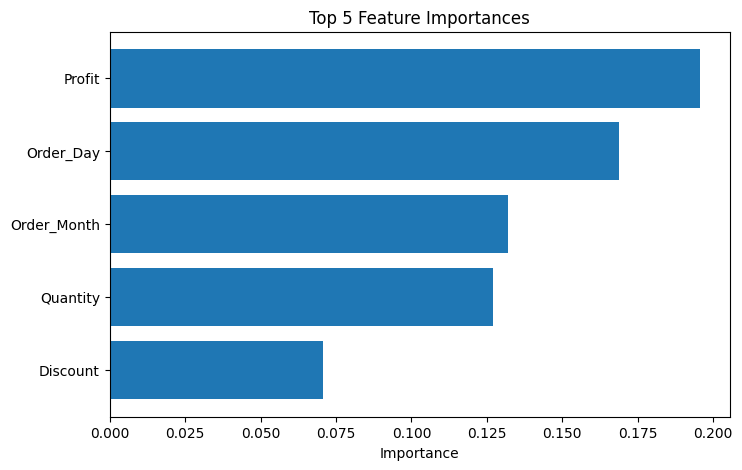

In [17]:

# Task 9.1 - Feature Importance

feature_importance = pd.DataFrame({

    "Feature": X.columns,
    "Importance": rf_model.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 5 Important Features")

top5 = feature_importance.head(5)

print(top5)

# Plot

plt.figure(figsize=(8,5))

plt.barh(
    top5["Feature"],
    top5["Importance"]
)

plt.xlabel("Importance")
plt.title("Top 5 Feature Importances")

plt.gca().invert_yaxis()

plt.show()

In [18]:

# Task 10 - Gradient Boosting

from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(

    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42

)

gb_model.fit(X_train_scaled, y_clf_train)

# Predictions
gb_train_pred = gb_model.predict(X_train_scaled)
gb_test_pred = gb_model.predict(X_test_scaled)

# Probabilities
gb_prob = gb_model.predict_proba(X_test_scaled)[:,1]

# Metrics
gb_train_acc = accuracy_score(y_clf_train, gb_train_pred)
gb_test_acc = accuracy_score(y_clf_test, gb_test_pred)
gb_auc = roc_auc_score(y_clf_test, gb_prob)

print("Gradient Boosting")

print("----------------------------")

print("Training Accuracy :", round(gb_train_acc,4))
print("Testing Accuracy  :", round(gb_test_acc,4))
print("ROC-AUC           :", round(gb_auc,4))

Gradient Boosting
----------------------------
Training Accuracy : 0.815
Testing Accuracy  : 0.51
ROC-AUC           : 0.4566


In [19]:

# Task 11 - Feature Ablation

# Lowest 5 important features

lowest5 = feature_importance.tail(5)

print("Lowest Importance Features")

print(lowest5)

remove_features = lowest5["Feature"].tolist()

# Remove columns

X_train_reduced = X_train.drop(columns=remove_features)

X_test_reduced = X_test.drop(columns=remove_features)

# Scale again

scaler2 = StandardScaler()

X_train_reduced_scaled = scaler2.fit_transform(X_train_reduced)

X_test_reduced_scaled = scaler2.transform(X_test_reduced)

# Train RF again

rf_reduced = RandomForestClassifier(

    n_estimators=100,
    max_depth=10,
    random_state=42

)

rf_reduced.fit(X_train_reduced_scaled, y_clf_train)

# Probability

reduced_prob = rf_reduced.predict_proba(X_test_reduced_scaled)[:,1]

reduced_auc = roc_auc_score(

    y_clf_test,
    reduced_prob

)

print("\nFull Model AUC    :", round(rf_auc,4))
print("Reduced Model AUC :", round(reduced_auc,4))

Lowest Importance Features
                     Feature  Importance
8   Ship Mode_Standard Class    0.024310
11               Region_East    0.023781
13               Region_West    0.023312
15       Category_Technology    0.023171
12              Region_South    0.021860

Full Model AUC    : 0.5989
Reduced Model AUC : 0.5695


In [20]:

# Task 12 - Cross Validation

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

cv = StratifiedKFold(

    n_splits=5,
    shuffle=True,
    random_state=42

)

models = {

    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=20,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )

}

print("5-Fold Cross Validation Results\n")

cv_results = []

for name, model in models.items():

    scores = cross_val_score(

        model,

        X_train_scaled,

        y_clf_train,

        cv=cv,

        scoring="roc_auc"

    )

    mean_auc = scores.mean()
    std_auc = scores.std()

    cv_results.append([

        name,
        mean_auc,
        std_auc

    ])

    print(f"{name}")
    print(f"Mean AUC : {mean_auc:.4f}")
    print(f"Std AUC  : {std_auc:.4f}")
    print()

cv_results = pd.DataFrame(

    cv_results,

    columns=["Model","Mean AUC","Std AUC"]

)

print(cv_results)

5-Fold Cross Validation Results

Logistic Regression
Mean AUC : 0.4848
Std AUC  : 0.0420

Decision Tree
Mean AUC : 0.5140
Std AUC  : 0.0192

Random Forest
Mean AUC : 0.5124
Std AUC  : 0.0507

Gradient Boosting
Mean AUC : 0.5039
Std AUC  : 0.0359

                 Model  Mean AUC   Std AUC
0  Logistic Regression  0.484836  0.042049
1        Decision Tree  0.513993  0.019231
2        Random Forest  0.512398  0.050679
3    Gradient Boosting  0.503879  0.035872


In [21]:

# Task 13 - GridSearchCV Pipeline


from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

# Build Pipeline
pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    RandomForestClassifier(random_state=42)
)

# Parameter Grid
param_grid = {
    "randomforestclassifier__n_estimators": [50, 100, 200],
    "randomforestclassifier__max_depth": [5, 10, None],
    "randomforestclassifier__min_samples_leaf": [1, 5]
}

# Cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Grid Search
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
)

# IMPORTANT: Use unscaled data
grid_search.fit(X_train, y_clf_train)

print("Best Parameters")
print(grid_search.best_params_)

print("\nBest Cross Validation AUC")
print(round(grid_search.best_score_,4))

best_pipeline = grid_search.best_estimator_

Best Parameters
{'randomforestclassifier__max_depth': 10, 'randomforestclassifier__min_samples_leaf': 1, 'randomforestclassifier__n_estimators': 50}

Best Cross Validation AUC
0.5254


In [22]:

# Task 14 - Manual Learning Curve

from sklearn.metrics import roc_auc_score

fractions = [0.2, 0.4, 0.6, 0.8, 1.0]

results = []

for frac in fractions:

    size = int(frac * len(X_train))

    X_subset = X_train.iloc[:size]
    y_subset = y_clf_train.iloc[:size]

    best_pipeline.fit(X_subset, y_subset)

    # Training AUC
    train_prob = best_pipeline.predict_proba(X_subset)[:,1]
    train_auc = roc_auc_score(y_subset, train_prob)

    # Test AUC
    test_prob = best_pipeline.predict_proba(X_test)[:,1]
    test_auc = roc_auc_score(y_clf_test, test_prob)

    results.append([

        frac,
        train_auc,
        test_auc

    ])

learning_curve = pd.DataFrame(

    results,

    columns=[
        "Training Fraction",
        "Training AUC",
        "Test AUC"
    ]

)

print(learning_curve)

   Training Fraction  Training AUC  Test AUC
0                0.2      1.000000  0.538434
1                0.4      1.000000  0.503485
2                0.6      1.000000  0.531919
3                0.8      1.000000  0.509495
4                1.0      0.999956  0.589293


In [23]:

# Task 15 - Save Best Model

import joblib

joblib.dump(

    best_pipeline,

    "best_model.pkl"

)

print("Model saved successfully as best_model.pkl")

Model saved successfully as best_model.pkl


In [24]:

# Task 16 - Reload Model

loaded_model = joblib.load("best_model.pkl")

# Two sample rows
sample_data = X_test.iloc[:2]

predictions = loaded_model.predict(sample_data)

print("Sample Input")

print(sample_data)

print("\nPredictions")

print(predictions)

Sample Input
     Quantity  Discount      Profit  Order_Year  Order_Month  Order_Day  \
521        10       0.0 -123.267129        2025            6          5   
737        12       0.0  151.169345        2026            1          7   

     Ship Mode_Same Day  Ship Mode_Second Class  Ship Mode_Standard Class  \
521               False                   False                     False   
737               False                   False                      True   

     Segment_Corporate  Segment_Home Office  Region_East  Region_South  \
521              False                 True         True         False   
737               True                False         True         False   

     Region_West  Category_Office Supplies  Category_Technology  
521        False                      True                False  
737        False                     False                False  

Predictions
[0 0]


In [25]:

# Task 17 - Model Comparison Table

summary = pd.DataFrame({

    "Model":[

        "Logistic Regression",
        "Controlled Decision Tree",
        "Random Forest",
        "Gradient Boosting"

    ],

    "5-Fold Mean AUC":[

        cv_results.loc[0,"Mean AUC"],
        cv_results.loc[1,"Mean AUC"],
        cv_results.loc[2,"Mean AUC"],
        cv_results.loc[3,"Mean AUC"]

    ],

    "5-Fold Std AUC":[

        cv_results.loc[0,"Std AUC"],
        cv_results.loc[1,"Std AUC"],
        cv_results.loc[2,"Std AUC"],
        cv_results.loc[3,"Std AUC"]

    ],

    "Test AUC":[

        test_auc,
        roc_auc_score(
            y_clf_test,
            tree_controlled.predict_proba(X_test_scaled)[:,1]
        ),
        rf_auc,
        gb_auc

    ]

})

summary = summary.sort_values(
    by="Test AUC",
    ascending=False
)

print(summary)

                      Model  5-Fold Mean AUC  5-Fold Std AUC  Test AUC
2             Random Forest         0.512398        0.050679  0.598889
0       Logistic Regression         0.484836        0.042049  0.589293
1  Controlled Decision Tree         0.513993        0.019231  0.484040
3         Gradient Boosting         0.503879        0.035872  0.456566


In [26]:

# Task 18 - Best Model Recommendation

best_model = summary.iloc[0]

print("Recommended Model")
print("-------------------------")

print("Model :", best_model["Model"])
print("Test AUC :", round(best_model["Test AUC"],4))
print("CV Mean AUC :", round(best_model["5-Fold Mean AUC"],4))
print("CV Std AUC :", round(best_model["5-Fold Std AUC"],4))

print("\nRecommendation:")
print(f"{best_model['Model']} is recommended because it achieved the highest "
      "test ROC-AUC while maintaining strong cross-validation performance "
      "and low variation across folds, indicating good generalization.")

Recommended Model
-------------------------
Model : Random Forest
Test AUC : 0.5989
CV Mean AUC : 0.5124
CV Std AUC : 0.0507

Recommendation:
Random Forest is recommended because it achieved the highest test ROC-AUC while maintaining strong cross-validation performance and low variation across folds, indicating good generalization.
